# TD3 Ablation Study — Portfolio Optimization
> **Thesis-Ready** | Twin Delayed DDPG (TD3) · Network-Markowitz


## ABLATION STUDY — TD3 VERSION (SAC diganti TD3)


## Perubahan utama dari versi SAC:


In [106]:
#   - action_space noise exploration (TD3 butuh noise, bukan entropy)
#   - sac_kwargs → td3_kwargs
#   - LearningCurveCallback tetap kompatibel
#   - Semua metrik, backtest, XAI tetap identik


## GLOBAL SETTINGS


In [107]:
SEEDS         = [42, 123, 77]
TRAIN_STEPS   = 10000
GAMMA_CENTER  = 0
SET_WINDOW    = 30
SET_REBALANCE = 7
REWARD_WINDOW = 20
CVAR_LEVEL    = 0.95
STAT_ALPHA    = 0.05

# REWARD WEIGHTS (Tunable)
W_CVAR    = 0.50  # Target utama: Minimasi Tail Loss
W_CALMAR  = 0.25  # Menghindari drawdown besar
W_SORTINO = 0.25  # Menjaga downside volatility rendah

ABLATION_CONFIGS = {
    # --- Baseline: Static Gamma ---
    'Comp_Static_Gamma0': {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 0.0},
    'Comp_Static_Gamma1': {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 1.0},
    'Comp_Static_Gamma2': {'use_network': True,  'use_market': False, 'extra_features': [], 'static_gamma': 2.0},

    # --- Proposed: E2 (Optimal Features) — now uses TD3 ---
    'E2_TD3': {'use_network': True, 'use_market': True, 'extra_features': []},
}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import warnings
import os
from scipy import stats
from scipy.optimize import minimize
import gymnasium as gym
from gymnasium import spaces

# ── TD3 import (bukan SAC) ─────────────────────────────────────
from stable_baselines3 import TD3
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.noise import NormalActionNoise, OrnsteinUhlenbeckActionNoise
from networkx.algorithms import community

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('td3_ablation_results', exist_ok=True)

print('Libraries loaded (TD3 version).')
print(f'Ablation configs: {list(ABLATION_CONFIGS.keys())}')
print(f'SEEDS={SEEDS} | TRAIN_STEPS={TRAIN_STEPS} | CVaR level={CVAR_LEVEL*100:.0f}%')




Libraries loaded (TD3 version).
Ablation configs: ['Comp_Static_Gamma0', 'Comp_Static_Gamma1', 'Comp_Static_Gamma2', 'E2_TD3']
SEEDS=[42, 123, 77] | TRAIN_STEPS=10000 | CVaR level=95%


## DATA LOADING


In [108]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
        print('USDT removed from assets.')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(file_data)

print(f'Assets ({len(assets)}): {assets}')
print(f'Training : {ret_train.index[0].date()} – {ret_train.index[-1].date()} ({len(ret_train)} days)')
print(f'Testing  : {ret_test.index[0].date()} – {ret_test.index[-1].date()} ({len(ret_test)} days)')




USDT removed from assets.
Assets (9): ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training : 2017-09-15 – 2019-03-02 (534 days)
Testing  : 2019-03-03 – 2019-10-17 (229 days)


## PORTFOLIO OPTIMIZATION


In [109]:

def apply_rmt_filter(returns_window):
    """Random Matrix Theory filter untuk denoising matriks korelasi."""
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1 / Q)) ** 2
    n_signal = np.sum(eigenvalues >= lambda_max)
    if n_signal == 0:
        eigenvalues[:-1] = 0
    else:
        eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    """Solver SLSQP. Fallback ke equal-weight jika infeasible."""
    fun = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    bounds = tuple((0, 1.0) for _ in range(n_assets))
    w0 = np.ones(n_assets) / n_assets
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0


def _build_mst_centrality(N, corr_f):
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full = nx.from_numpy_array(dist_mat)
    mst = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=300)
        cent_vec = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return mst, cent_vec


def get_centrality_weights(returns_window, gamma=0.0):
    T, N = returns_window.shape
    mu     = returns_window.mean().values
    sigma  = returns_window.std().values
    corr_f = apply_rmt_filter(returns_window)
    cov_f  = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    _, cent_vec = _build_mst_centrality(N, corr_f)
    return _solve_weights(cov_f, cent_vec, mu, gamma, N)


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    return _solve_weights(cov_f, cent_vec, mu, gamma, len(mu))


def compute_classic_mv_weights(returns_window):
    """Classic Markowitz Mean-Variance (pure sample covariance, no RMT)."""
    T, N = returns_window.shape
    mu   = returns_window.mean().values
    cov  = np.cov(returns_window.values.T) + np.eye(N) * 1e-8
    w0     = np.ones(N) / N
    bounds = tuple((0.0, 1.0) for _ in range(N))
    fun = lambda w: w @ cov @ w
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0




## METRICS


In [110]:

def _compute_drawdown(arr):
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    return (cumulative - peak) / peak, cumulative


def calculate_annualized_return(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    n = len(arr)
    if n == 0: return np.nan
    total = (1 + arr).prod()
    if total <= 0: return np.nan
    return total ** (periods_per_year / n) - 1


def calculate_sharpe_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    if ann_vol <= 0 or np.isnan(ann_ret): return 0.0
    return ann_ret / ann_vol


def calculate_sortino_ratio(ret_series, periods_per_year=252, mar=0.0):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    downside = arr[arr < mar]
    if len(downside) == 0: return 0.0
    downside_dev = np.std(downside) * np.sqrt(periods_per_year)
    if downside_dev <= 0 or np.isnan(ann_ret): return 0.0
    return ann_ret / downside_dev


def calculate_calmar_ratio(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    drawdown, _ = _compute_drawdown(arr)
    max_dd = drawdown.min()
    if max_dd == 0 or np.isnan(ann_ret): return 0.0
    return ann_ret / abs(max_dd)


def calculate_cvar(ret_series, confidence=0.95):
    arr = np.array(ret_series)
    var = np.percentile(arr, (1 - confidence) * 100)
    tail_losses = arr[arr <= var]
    if len(tail_losses) == 0: return 0.0
    return float(-np.mean(tail_losses))


def calculate_all_metrics(ret_series, cvar_level=0.95, periods_per_year=252):
    arr = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    total_ret = (1 + arr).prod() - 1
    drawdown, _ = _compute_drawdown(arr)
    max_dd = drawdown.min()
    downside = arr[arr < 0]
    down_std = np.std(downside) * np.sqrt(periods_per_year) if len(downside) > 0 else 0.0
    return {
        'Sharpe Ratio'    : calculate_sharpe_ratio(arr, periods_per_year),
        'Sortino Ratio'   : calculate_sortino_ratio(arr, periods_per_year),
        'Calmar Ratio'    : calculate_calmar_ratio(arr, periods_per_year),
        'CVaR (95%)'      : calculate_cvar(arr, cvar_level),
        'Total Return'    : total_ret,
        'Ann. Return'     : ann_ret,
        'Ann. Volatility' : ann_vol,
        'Downside Std'    : down_std,
        'Max Drawdown'    : max_dd,
    }




## VISUALISATION HELPERS


In [111]:

ABLATION_COLORS = {
    'E2_TD3'             : '#2196F3',
    'Comp_Static_Gamma0' : '#9E9E9E',
    'Comp_Static_Gamma1' : '#795548',
    'Comp_Static_Gamma2' : '#607D8B',
    'Classic-MV'         : '#9C27B0',
}

MAIN_EXPS = ['Comp_Static_Gamma0', 'Comp_Static_Gamma1', 'Comp_Static_Gamma2',
             'E2_TD3', 'Classic-MV']

METRIC_KEY = {
    'Sharpe Ratio' : 'SharpeRatio',
    'Sortino Ratio': 'SortinoRatio',
    'Calmar Ratio' : 'CalmarRatio',
    'CVaR (95%)'   : 'CVaR95pct',
}
FOUR_METRICS = list(METRIC_KEY.keys())


def get_display_name(exp_id):
    name = exp_id.replace('_', ' ')
    if 'Static' in exp_id or exp_id == 'Classic-MV':
        return f"{name} (Det)"
    return name


def _style_table(tbl, col_labels, n_rows):
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#1565C0')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, n_rows + 1):
        fc = '#E3F2FD' if i % 2 == 0 else 'white'
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor(fc)


def _plot_metric_bars(ax, summary_df, exp_ids, colors, mean_col, std_col,
                      label, lower_better, short_labels=True):
    vals = summary_df.loc[exp_ids, mean_col].values
    errs = summary_df.loc[exp_ids, std_col].values
    bars = ax.bar(range(len(exp_ids)), vals, yerr=errs,
                  color=colors, edgecolor='white', capsize=3, alpha=0.85)
    best_idx = np.argmin(vals) if lower_better else np.argmax(vals)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(range(len(exp_ids)))
    xlabels = ([e.split('_')[0] for e in exp_ids] if short_labels
               else [e.replace('_', '\n') for e in exp_ids])
    ax.set_xticklabels(xlabels, fontsize=7)
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_ylabel(label, fontsize=8)
    return bars, vals, errs


def _mean_cumret(ablation_results, exp_id, period):
    return pd.concat(
        [ablation_results[exp_id][period][s] for s in SEEDS], axis=1
    ).mean(axis=1)


def _build_heatmap_data(summary_df, exp_ids, period):
    metric_cols = [(f'{METRIC_KEY[m]}_{period}_Mean', m.split()[0]) for m in FOUR_METRICS]
    metric_cols[-1] = (f'CVaR95pct_{period}_Mean', 'CVaR(95%)')
    heatmap_data = pd.DataFrame(
        {lbl: summary_df[col] for col, lbl in metric_cols},
        index=exp_ids
    ).astype(float)
    heatmap_norm = heatmap_data.copy()
    for col in ['Sharpe', 'Sortino', 'Calmar']:
        mn, mx = heatmap_norm[col].min(), heatmap_norm[col].max()
        heatmap_norm[col] = (heatmap_norm[col] - mn) / (mx - mn + 1e-8)
    mn, mx = heatmap_norm['CVaR(95%)'].min(), heatmap_norm['CVaR(95%)'].max()
    heatmap_norm['CVaR(95%)'] = 1 - (heatmap_norm['CVaR(95%)'] - mn) / (mx - mn + 1e-8)
    return heatmap_data, heatmap_norm


print('Core functions defined.')




Core functions defined.


## FEATURE ENGINEERING


In [112]:

def compute_network_features(returns_window):
    T, N = returns_window.shape
    corr_f = apply_rmt_filter(returns_window)
    mst, cent_vec = _build_mst_centrality(N, corr_f)
    mst_dist = sum(d['weight'] for _, _, d in mst.edges(data=True))
    spectral_gap = nx.algebraic_connectivity(mst)
    return np.array([
        mst_dist     * 0.1,
        spectral_gap,
    ], dtype=np.float32), corr_f, cent_vec


def compute_market_features(returns_window, port_val=0.0):
    arr = returns_window.values
    T, N = arr.shape
    window_5  = max(1, min(5, T))
    window_20 = max(1, min(20, T))
    rolling_vol_5  = arr[-window_5:].std(axis=0).mean()
    rolling_vol_20 = arr[-window_20:].std(axis=0).mean()
    vol_ratio      = rolling_vol_5 / (rolling_vol_20 + 1e-8)
    mom_5d    = arr[-window_5:].mean(axis=0).mean()
    mom_20d   = arr[-window_20:].mean(axis=0).mean()
    mom_cross = mom_5d - mom_20d
    ma_20       = arr[-window_20:].mean(axis=0)
    ret_5d_per  = arr[-window_5:].mean(axis=0)
    pct_uptrend = float(np.mean(ret_5d_per > ma_20))
    return np.array([
        rolling_vol_5  * 100,
        rolling_vol_20 * 100,
        vol_ratio,
        mom_5d    * 100,
        mom_20d   * 100,
        mom_cross * 100,
        pct_uptrend,
    ], dtype=np.float32)


def compute_extra_features(returns_window, corr_f, extra_list):
    extra = []
    if 'downside_vol' in extra_list:
        ret_flat = returns_window.values.flatten()
        downside = ret_flat[ret_flat < 0]
        dv = np.std(downside) * np.sqrt(252) if len(downside) > 0 else 0.0
        extra.append(float(dv) * 10)
    if 'avg_corr' in extra_list:
        upper_tri = corr_f[np.triu_indices_from(corr_f, k=1)]
        extra.append(float(np.mean(np.abs(upper_tri))))
    return np.array(extra, dtype=np.float32)




## GLOBAL PRECOMPUTE CACHE


In [113]:
print('=== Phase 4: Global Precompute Cache ===')
GLOBAL_CACHE = {}

print(f'Menghitung cache training: {len(ret_train) - SET_WINDOW} windows...')
for i in range(SET_WINDOW, len(ret_train)):
    win   = ret_train.iloc[i - SET_WINDOW: i]
    mu    = win.mean().values
    sigma = win.std().values
    nw_feat_full, corr_f, cent_vec = compute_network_features(win)
    T, N  = win.shape
    cov_f = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    GLOBAL_CACHE[i] = {
        'win': win, 'corr_f': corr_f, 'cent_vec': cent_vec,
        'cov_f': cov_f, 'mu': mu, 'sigma': sigma,
        'nw_feat_full': nw_feat_full,
    }

feat_matrix_train = np.stack([GLOBAL_CACHE[i]['nw_feat_full'] for i in sorted(GLOBAL_CACHE.keys())])
FEAT_MEAN = feat_matrix_train.mean(axis=0)
FEAT_STD  = feat_matrix_train.std(axis=0) + 1e-8

print(f'Menghitung cache testing: {len(ret_test) - SET_WINDOW} windows...')
for i in range(SET_WINDOW, len(ret_test)):
    win   = ret_test.iloc[i - SET_WINDOW: i]
    mu    = win.mean().values
    sigma = win.std().values
    nw_feat_full, corr_f, cent_vec = compute_network_features(win)
    T, N  = win.shape
    cov_f = np.outer(sigma, sigma) * corr_f + np.eye(N) * 1e-8
    global_idx = len(ret_train) + i
    GLOBAL_CACHE[global_idx] = {
        'win': win, 'corr_f': corr_f, 'cent_vec': cent_vec,
        'cov_f': cov_f, 'mu': mu, 'sigma': sigma,
        'nw_feat_full': nw_feat_full,
    }

print(f'Global cache selesai: {len(GLOBAL_CACHE)} windows cached.')


def normalize_features(nw_feat):
    return (nw_feat - FEAT_MEAN) / FEAT_STD


def build_observation(returns_window, config, port_val=0.0, nw_feat_raw=None, corr_f=None):
    if nw_feat_raw is None or corr_f is None:
        nw_feat_raw, corr_f, cent_vec = compute_network_features(returns_window)
    nw_feat    = normalize_features(nw_feat_raw)
    mkt_feat   = compute_market_features(returns_window, port_val)
    extra_feat = compute_extra_features(returns_window, corr_f, config['extra_features'])
    parts = []
    if config['use_network']: parts.append(nw_feat)
    if config['use_market']:  parts.append(mkt_feat)
    if len(extra_feat) > 0:   parts.append(extra_feat)
    obs = np.concatenate(parts) if parts else np.array([0.0], dtype=np.float32)
    return np.nan_to_num(obs), corr_f, None


def get_obs_dim(config):
    dim = 0
    if config['use_network']: dim += 2
    if config['use_market']:  dim += 7
    dim += len(config['extra_features'])
    return max(dim, 1)


def build_caches_from_global(config, global_cache):
    obs_cache, opt_cache = {}, {}
    for i, data in global_cache.items():
        obs, _, _ = build_observation(
            data['win'], config, port_val=0.0,
            nw_feat_raw=data['nw_feat_full'], corr_f=data['corr_f']
        )
        obs_cache[i] = obs
        opt_cache[i] = (data['cov_f'], data['cent_vec'], data['mu'])
    return obs_cache, opt_cache


print('Feature engineering functions defined.')
print('Observation dimensions per config:')
for name, cfg in ABLATION_CONFIGS.items():
    print(f'  {name}: {get_obs_dim(cfg)} features')




=== Phase 4: Global Precompute Cache ===
Menghitung cache training: 504 windows...
Menghitung cache testing: 199 windows...
Global cache selesai: 703 windows cached.
Feature engineering functions defined.
Observation dimensions per config:
  Comp_Static_Gamma0: 2 features
  Comp_Static_Gamma1: 2 features
  Comp_Static_Gamma2: 2 features
  E2_TD3: 9 features


## ENVIRONMENT


In [114]:

class AblationPortfolioEnv(gym.Env):
    """
    Portfolio env yang kompatibel dengan TD3.
    TD3 butuh action_space kontinu — sama dengan versi SAC.
    Perbedaan: TD3 menggunakan deterministik policy + action noise eksternal,
    bukan entropy regularization internal seperti SAC.
    """
    def __init__(self, returns_data, obs_cache, opt_cache,
                 config, window_size=30, gamma_center=0.0, data_start_offset=0):
        super().__init__()
        self.data              = returns_data
        self.obs_cache         = obs_cache
        self.opt_cache         = opt_cache
        self.config            = config
        self.window_size       = window_size
        self.gamma_center      = gamma_center
        self.data_start_offset = data_start_offset
        self.current_step      = window_size
        self.port_val          = 1.0
        self.peak_val          = 1.0
        self._returns_buffer   = []
        self._reward_window    = REWARD_WINDOW
        self._rew_mean  = 0.0
        self._rew_M2    = 0.0
        self._rew_count = 0

        obs_dim = get_obs_dim(config)
        # TD3 action space: kontinu [-1, 1] (akan di-clip & dishift ke gamma)
        self.action_space      = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf,
                                            shape=(obs_dim,), dtype=np.float32)

    def _get_obs(self):
        global_idx = self.data_start_offset + self.current_step
        return self.obs_cache[global_idx].copy()

    def _normalize_reward(self, r):
        self._rew_count += 1
        delta = r - self._rew_mean
        self._rew_mean += delta / self._rew_count
        delta2 = r - self._rew_mean
        self._rew_M2 += delta * delta2
        var = self._rew_M2 / self._rew_count if self._rew_count > 1 else 1.0
        std = max(np.sqrt(var), 1e-6)
        return float(np.clip(r / std, -10.0, 10.0))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step    = self.window_size
        self.port_val        = 1.0
        self.peak_val        = 1.0
        self._returns_buffer = []
        self._rew_mean       = 0.0
        self._rew_M2         = 0.0
        self._rew_count      = 0
        return self._get_obs(), {}

    def step(self, action):
        # TD3 action range [-1,1] → scale ke gamma range [-5, 5]
        gamma = float(np.clip(action[0], -1.0, 1.0)) * 5.0 + self.gamma_center
        global_idx = self.data_start_offset + self.current_step
        cov_f, cent_vec, mu = self.opt_cache[global_idx]
        w        = fast_centrality_weights(cov_f, cent_vec, mu, gamma)
        port_ret = np.dot(w, self.data.iloc[self.current_step].values)

        self.port_val *= (1 + port_ret)
        self.peak_val  = max(self.peak_val, self.port_val)

        self._returns_buffer.append(port_ret)
        if len(self._returns_buffer) > self._reward_window:
            self._returns_buffer.pop(0)

        arr = np.array(self._returns_buffer)
        if len(arr) < 5:  # Butuh buffer minimum untuk metrik risiko
            raw_reward = port_ret * 100
        else:
            # 1. Calmar Ratio (Annualized Return / Max Drawdown)
            calmar = calculate_calmar_ratio(arr)
            
            # 2. Sortino Ratio (Annualized Return / Downside Deviation)
            sortino = calculate_sortino_ratio(arr)
            
            # 3. CVaR (Expected Tail Loss)
            # Karena CVaR adalah loss (positif), kita beri penalti (-CVaR)
            cvar_val = calculate_cvar(arr, confidence=CVAR_LEVEL)
            
            # Gabungkan dengan bobot
            # Skalasi: Calmar/Sortino biasanya 0-5, CVaR harian ~0.02 (x100 = 2)
            raw_reward = (W_CALMAR * calmar) + \
                         (W_SORTINO * sortino) - \
                         (W_CVAR * cvar_val * 100)
            
            raw_reward = float(np.clip(raw_reward, -15.0, 15.0))

        reward = self._normalize_reward(raw_reward)
        self.current_step += 1
        done = self.current_step >= len(self.data) - 1
        obs  = self._get_obs() if not done else np.zeros(self.observation_space.shape)
        return obs, reward, done, False, {}


print('AblationPortfolioEnv defined (TD3-compatible action space).')




AblationPortfolioEnv defined (TD3-compatible action space).


## LEARNING CURVE CALLBACK


In [115]:

class LearningCurveCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self._current_ep_reward = 0.0

    def _on_step(self):
        reward = self.locals.get('rewards', [0])[0]
        done   = self.locals.get('dones', [False])[0]
        self._current_ep_reward += reward
        if done:
            self.episode_rewards.append(self._current_ep_reward)
            self._current_ep_reward = 0.0
        return True

    def get_smoothed(self, window=20):
        r = np.array(self.episode_rewards)
        if len(r) < window:
            return r
        return np.convolve(r, np.ones(window) / window, mode='valid')


if 'learning_curves' not in globals():
    learning_curves = {}

print('LearningCurveCallback defined.')




LearningCurveCallback defined.


## TD3 HYPERPARAMETERS


In [116]:
# Perbedaan utama TD3 vs SAC:
#   - policy_noise: Gaussian noise ditambahkan ke target policy (smoothing)
#   - noise_clip  : membatasi target policy noise
#   - target_policy_noise & delay: TD3 update actor lebih jarang dari critic
#   - action noise: NormalActionNoise untuk eksplorasi (SAC pakai entropy)
#   - TIDAK ada ent_coef karena TD3 deterministik

TD3_POLICY_KWARGS = dict(
    net_arch=[256, 256],  # arsitektur sama dengan SAC default
)

td3_kwargs = {
    'policy'              : 'MlpPolicy',
    'learning_rate'       : 3e-4,
    'buffer_size'         : 50000,
    'batch_size'          : 256,
    'train_freq'          : 1,
    'gradient_steps'      : 1,
    'learning_starts'     : 200,
    'tau'                 : 0.005,
    'gamma'               : 0.99,
    'policy_delay'        : 2,           # TD3: update actor setiap 2 critic update
    'target_policy_noise' : 0.2,         # TD3: noise pada target policy
    'target_noise_clip'   : 0.5,         # TD3: clip target noise
    'policy_kwargs'       : TD3_POLICY_KWARGS,
}

print('TD3 hyperparameters set.')
print(f'  policy_delay={td3_kwargs["policy_delay"]} | '
      f'target_policy_noise={td3_kwargs["target_policy_noise"]} | '
      f'target_noise_clip={td3_kwargs["target_noise_clip"]}')




TD3 hyperparameters set.
  policy_delay=2 | target_policy_noise=0.2 | target_noise_clip=0.5


## TRAINING (TD3)


In [117]:

if 'trained_model_paths' not in globals():
    trained_model_paths = {}

sep = '=' * 60

for exp_id, config in ABLATION_CONFIGS.items():
    print(f'\n{sep}')
    print(f'Experiment: {exp_id} | obs_dim={get_obs_dim(config)}')

    obs_cache, opt_cache = build_caches_from_global(config, GLOBAL_CACHE)

    for seed in SEEDS:
        if config.get('static_gamma') is not None:
            if seed == SEEDS[0]:
                print(f'  Static benchmark {exp_id} — tidak perlu training.')
            trained_model_paths[(exp_id, seed)] = 'static'
            continue

        print(f'  Training TD3 seed={seed} | TRAIN_STEPS={TRAIN_STEPS}...')

        env = AblationPortfolioEnv(
            ret_train, obs_cache, opt_cache, config,
            window_size=SET_WINDOW, gamma_center=GAMMA_CENTER,
        )

        # ── Action noise untuk TD3 (menggantikan entropy exploration SAC) ──
        # NormalActionNoise: Gaussian noise pada action saat training
        # sigma=0.1 → eksplorasi moderat pada action space [-1, 1]
        n_actions = env.action_space.shape[-1]
        action_noise = NormalActionNoise(
            mean=np.zeros(n_actions),
            sigma=0.1 * np.ones(n_actions)
        )

        lc_callback = LearningCurveCallback()

        model = TD3(
            env=env,
            seed=seed,
            verbose=0,
            action_noise=action_noise,
            **td3_kwargs
        )
        model.learn(total_timesteps=TRAIN_STEPS, callback=lc_callback, progress_bar=True)

        learning_curves[(exp_id, seed)] = lc_callback
        model_name = f'td3_{exp_id}_seed{seed}'
        model.save(model_name)
        trained_model_paths[(exp_id, seed)] = model_name
        print(f'    Saved: {model_name}.zip | Episodes: {len(lc_callback.episode_rewards)}')

print('\n=== Semua model TD3 ablation selesai dilatih ===')





Experiment: Comp_Static_Gamma0 | obs_dim=2
  Static benchmark Comp_Static_Gamma0 — tidak perlu training.

Experiment: Comp_Static_Gamma1 | obs_dim=2
  Static benchmark Comp_Static_Gamma1 — tidak perlu training.

Experiment: Comp_Static_Gamma2 | obs_dim=2
  Static benchmark Comp_Static_Gamma2 — tidak perlu training.

Experiment: E2_TD3 | obs_dim=9
  Training TD3 seed=42 | TRAIN_STEPS=10000...


Output()

Output()

    Saved: td3_E2_TD3_seed42.zip | Episodes: 19
  Training TD3 seed=123 | TRAIN_STEPS=10000...


Output()

    Saved: td3_E2_TD3_seed123.zip | Episodes: 19
  Training TD3 seed=77 | TRAIN_STEPS=10000...


    Saved: td3_E2_TD3_seed77.zip | Episodes: 19

=== Semua model TD3 ablation selesai dilatih ===


## PLOT LEARNING CURVES


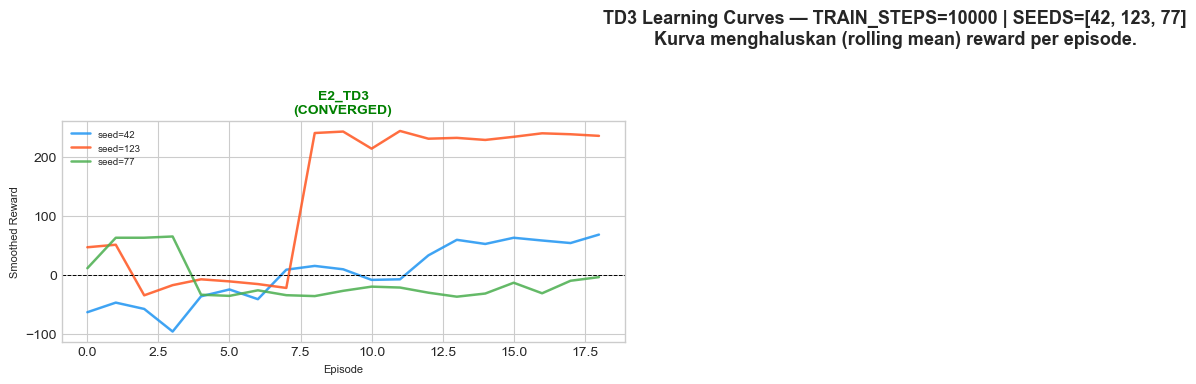

Saved: td3_ablation_results/learning_curves_td3.png


In [118]:

sac_configs = [k for k, v in ABLATION_CONFIGS.items() if v.get('static_gamma') is None]
n_configs = len(sac_configs)
ncols = 3
nrows = (n_configs + ncols - 1) // ncols

fig, axes = plt.subplots(max(nrows, 1), ncols, figsize=(18, max(nrows, 1) * 4))
fig.suptitle(f'TD3 Learning Curves — TRAIN_STEPS={TRAIN_STEPS} | SEEDS={SEEDS}\n'
             f'Kurva menghaluskan (rolling mean) reward per episode.',
             fontsize=13, fontweight='bold')

axes_flat = np.array(axes).flatten()
seed_colors = {42: '#2196F3', 123: '#FF5722', 77: '#4CAF50'}

for ax, exp_id in zip(axes_flat, sac_configs):
    converged_count = 0
    for seed in SEEDS:
        key = (exp_id, seed)
        if key not in learning_curves:
            continue
        lc = learning_curves[key]
        raw = np.array(lc.episode_rewards)
        if len(raw) == 0:
            continue
        smoothed = lc.get_smoothed(window=20)
        ax.plot(np.arange(len(smoothed)), smoothed, color=seed_colors[seed],
                linewidth=1.8, label=f'seed={seed}', alpha=0.85)
        ax.plot(np.arange(len(raw)), raw, color=seed_colors[seed],
                linewidth=0.4, alpha=0.2)
        # Simple convergence check: last 20% mean > first 20% mean and positive
        if len(smoothed) > 10 and smoothed[-1] > smoothed[len(smoothed)//5] and smoothed[-1] > 0:
            converged_count += 1

    status = '(CONVERGED)' if converged_count >= len(SEEDS) // 2 + 1 else '(CHECK)'
    ax.set_title(f'{exp_id}\n{status}', fontsize=10, fontweight='bold',
                 color='green' if 'CONVERGED' in status else 'red')
    ax.set_xlabel('Episode', fontsize=8)
    ax.set_ylabel('Smoothed Reward', fontsize=8)
    ax.legend(fontsize=7)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.7)

for ax in axes_flat[len(sac_configs):]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('td3_ablation_results/learning_curves_td3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: td3_ablation_results/learning_curves_td3.png')




## STRATEGY & BACKTEST


In [119]:

class AblationStrategy:
    def __init__(self, name, model_path, config, gamma_center=0.0, global_cache=None):
        self.name         = name
        self.config       = config
        self.gamma_center = gamma_center
        self.global_cache = global_cache
        self.is_static    = config.get('static_gamma') is not None
        if self.is_static:
            self.model      = None
            self.last_gamma = config['static_gamma']
        else:
            # Load TD3 model
            self.model      = TD3.load(model_path)
            self.last_gamma = gamma_center

    def compute_weights(self, returns_window, port_val=1.0, step_idx=None):
        cached_data = None
        if self.global_cache is not None and step_idx is not None and step_idx in self.global_cache:
            cached_data = self.global_cache[step_idx]

        if self.is_static:
            self.last_gamma = self.config['static_gamma']
        else:
            if cached_data is not None:
                obs, _, _ = build_observation(
                    returns_window, self.config, port_val=port_val - 1.0,
                    nw_feat_raw=cached_data['nw_feat_full'], corr_f=cached_data['corr_f']
                )
            else:
                obs, _, _ = build_observation(returns_window, self.config, port_val=port_val - 1.0)

            # TD3 predict: deterministic=True (TD3 selalu deterministik saat inference)
            action, _ = self.model.predict(obs, deterministic=True)
            # Scale action dari [-1,1] ke gamma range [-5,5]
            self.last_gamma = float(np.clip(action[0], -1.0, 1.0)) * 5.0 + self.gamma_center

        if cached_data is not None:
            return fast_centrality_weights(
                cached_data['cov_f'], cached_data['cent_vec'],
                cached_data['mu'], self.last_gamma
            )
        return get_centrality_weights(returns_window, gamma=self.last_gamma)


def run_backtest(strategy, data, window=30, rebalance_freq=7, data_start_offset=0):
    rets, dates, gamma_history = [], [], []
    current_weights = None
    port_val        = 1.0
    for i in range(window, len(data)):
        if (i - window) % rebalance_freq == 0:
            window_df  = data.iloc[i - window: i]
            global_idx = data_start_offset + i
            current_weights = strategy.compute_weights(
                window_df,
                port_val=(1.0 if strategy.is_static else port_val),
                step_idx=global_idx
            )
        if current_weights is not None:
            daily_ret = np.dot(current_weights, data.iloc[i].values)
            port_val  = port_val * (1 + daily_ret)
            rets.append(daily_ret)
            dates.append(data.index[i])
            gamma_history.append(getattr(strategy, 'last_gamma', 1.0))
    return (pd.Series(rets, index=dates, name=strategy.name),
            pd.Series(gamma_history, index=dates))


def run_backtest_baselines(data, assets, window=30):
    n_assets = len(assets)
    dates = data.index[window:]
    cmv_rets = []
    w_mv = np.ones(n_assets) / n_assets
    for i in range(window, len(data)):
        if (i - window) % 7 == 0:
            win  = data.iloc[i - window: i]
            w_mv = compute_classic_mv_weights(win)
        cmv_rets.append(np.dot(w_mv, data.iloc[i].values))
    return {'Classic-MV': pd.Series(cmv_rets, index=dates)}


print('Backtest engine defined (TD3-compatible).')




Backtest engine defined (TD3-compatible).


## RUN BACKTEST


In [120]:

ablation_results = {}

for exp_id, config in ABLATION_CONFIGS.items():
    print(f'\nBacktest: {exp_id}')
    ablation_results[exp_id] = {'train': {}, 'test': {}}

    for seed in SEEDS:
        model_path = trained_model_paths[(exp_id, seed)]
        strat = AblationStrategy(
            f'{exp_id}_s{seed}', model_path, config, GAMMA_CENTER,
            global_cache=GLOBAL_CACHE
        )
        ret_tr, _ = run_backtest(strat, ret_train, SET_WINDOW, SET_REBALANCE,
                                 data_start_offset=0)
        ablation_results[exp_id]['train'][seed] = ret_tr

        ret_te, _ = run_backtest(strat, ret_test, SET_WINDOW, SET_REBALANCE,
                                 data_start_offset=len(ret_train))
        ablation_results[exp_id]['test'][seed] = ret_te

        m_tr = calculate_all_metrics(ret_tr, CVAR_LEVEL)
        m_te = calculate_all_metrics(ret_te, CVAR_LEVEL)
        print(f'  [TRAIN] seed={seed} | Sharpe={m_tr["Sharpe Ratio"]:.3f} | '
              f'Calmar={m_tr["Calmar Ratio"]:.3f} | CVaR={m_tr["CVaR (95%)"]:.4f}')
        print(f'  [TEST ] seed={seed} | Sharpe={m_te["Sharpe Ratio"]:.3f} | '
              f'Calmar={m_te["Calmar Ratio"]:.3f} | CVaR={m_te["CVaR (95%)"]:.4f}')

print('Running Baselines (Classic-MV)...')
baselines_train = run_backtest_baselines(ret_train, assets, SET_WINDOW)
baselines_test  = run_backtest_baselines(ret_test,  assets, SET_WINDOW)

for b_name in ['Classic-MV']:
    ablation_results[b_name] = {'train': {}, 'test': {}}
    for seed in SEEDS:
        ablation_results[b_name]['train'][seed] = baselines_train[b_name]
        ablation_results[b_name]['test'][seed]  = baselines_test[b_name]

    m_tr = calculate_all_metrics(baselines_train[b_name], CVAR_LEVEL)
    m_te = calculate_all_metrics(baselines_test[b_name],  CVAR_LEVEL)
    print(f'  [BASELINE: {b_name}]')
    print(f'    TRAIN: Sharpe={m_tr["Sharpe Ratio"]:.3f} | Calmar={m_tr["Calmar Ratio"]:.3f}')
    print(f'    TEST : Sharpe={m_te["Sharpe Ratio"]:.3f} | Calmar={m_te["Calmar Ratio"]:.3f}')

print('\nSemua backtest selesai.')





Backtest: Comp_Static_Gamma0
  [TRAIN] seed=42 | Sharpe=-0.417 | Calmar=-0.344 | CVaR=0.1159
  [TEST ] seed=42 | Sharpe=-0.075 | Calmar=-0.085 | CVaR=0.0985
  [TRAIN] seed=123 | Sharpe=-0.417 | Calmar=-0.344 | CVaR=0.1159
  [TEST ] seed=123 | Sharpe=-0.075 | Calmar=-0.085 | CVaR=0.0985
  [TRAIN] seed=77 | Sharpe=-0.417 | Calmar=-0.344 | CVaR=0.1159
  [TEST ] seed=77 | Sharpe=-0.075 | Calmar=-0.085 | CVaR=0.0985

Backtest: Comp_Static_Gamma1
  [TRAIN] seed=42 | Sharpe=-0.663 | Calmar=-0.620 | CVaR=0.1250
  [TEST ] seed=42 | Sharpe=-0.104 | Calmar=-0.118 | CVaR=0.0976
  [TRAIN] seed=123 | Sharpe=-0.663 | Calmar=-0.620 | CVaR=0.1250
  [TEST ] seed=123 | Sharpe=-0.104 | Calmar=-0.118 | CVaR=0.0976
  [TRAIN] seed=77 | Sharpe=-0.663 | Calmar=-0.620 | CVaR=0.1250
  [TEST ] seed=77 | Sharpe=-0.104 | Calmar=-0.118 | CVaR=0.0976

Backtest: Comp_Static_Gamma2
  [TRAIN] seed=42 | Sharpe=-0.663 | Calmar=-0.620 | CVaR=0.1250
  [TEST ] seed=42 | Sharpe=-0.104 | Calmar=-0.118 | CVaR=0.0976
  [TRAIN] 

## SUMMARY TABLE


In [121]:

def _agg(metrics_list, key):
    vals = [m[key] for m in metrics_list]
    return np.nanmean(vals), np.nanstd(vals)


summary_rows = []
ALL_IDS = list(ABLATION_CONFIGS.keys()) + ['Classic-MV']

for exp_id in ALL_IDS:
    config = ABLATION_CONFIGS.get(exp_id, {})
    train_metrics = [calculate_all_metrics(ablation_results[exp_id]['train'][s], CVAR_LEVEL) for s in SEEDS]
    test_metrics  = [calculate_all_metrics(ablation_results[exp_id]['test'][s],  CVAR_LEVEL) for s in SEEDS]

    if exp_id == 'Classic-MV':
        feature_desc = ['Standard Baseline (Deterministic)']
    elif config.get('static_gamma') is not None:
        feature_desc = [f'Static Gamma {config["static_gamma"]} (Deterministic)']
    else:
        feature_desc  = (['Network(2)'] if config['use_network'] else [])
        feature_desc += (['Market(7)']  if config['use_market']  else [])
        feature_desc += config['extra_features']

    row = {
        'Experiment': exp_id,
        'Features'  : ' + '.join(feature_desc),
        'Obs Dim'   : get_obs_dim(config) if exp_id in ABLATION_CONFIGS else 0,
    }

    for period, metrics_list in [('Train', train_metrics), ('Test', test_metrics)]:
        for metric in FOUR_METRICS:
            mean, std = _agg(metrics_list, metric)
            col_key = METRIC_KEY[metric]
            row[f'{col_key}_{period}_Mean'] = mean
            row[f'{col_key}_{period}_Std']  = std

    tr_ann_m, _ = _agg(train_metrics, 'Ann. Return')
    te_ann_m, _ = _agg(test_metrics,  'Ann. Return')
    tr_tot_m, _ = _agg(train_metrics, 'Total Return')
    te_tot_m, _ = _agg(test_metrics,  'Total Return')
    row['AnnRet_Train_Mean'] = tr_ann_m
    row['AnnRet_Test_Mean']  = te_ann_m
    row['TotalRet_Gap']      = tr_tot_m - te_tot_m
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Experiment')
summary_df.to_csv('td3_ablation_results/td3_ablation_summary.csv')

sep = '=' * 90
print(sep)
print('TD3 ABLATION STUDY — 4 METRIK UTAMA (Testing Period)')
print(sep)
print(f'{"Experiment":<25} {"Sharpe":>10} {"Sortino":>10} {"Calmar":>10} {"CVaR(95%)":>12}')
print('-' * 70)
for exp_id, row in summary_df.iterrows():
    print(f'{exp_id:<25} '
          f'{row["SharpeRatio_Test_Mean"]:>10.4f} '
          f'{row["SortinoRatio_Test_Mean"]:>10.4f} '
          f'{row["CalmarRatio_Test_Mean"]:>10.4f} '
          f'{row["CVaR95pct_Test_Mean"]:>12.5f}')
print(sep)




TD3 ABLATION STUDY — 4 METRIK UTAMA (Testing Period)
Experiment                    Sharpe    Sortino     Calmar    CVaR(95%)
----------------------------------------------------------------------
Comp_Static_Gamma0           -0.0752    -0.0947    -0.0846      0.09853
Comp_Static_Gamma1           -0.1039    -0.1349    -0.1178      0.09764
Comp_Static_Gamma2           -0.1039    -0.1349    -0.1178      0.09764
E2_TD3                        0.2871     0.3877     0.3697      0.11367
Classic-MV                   -0.1054    -0.1335    -0.1188      0.09784


## STATISTICAL TESTS (Wilcoxon)


In [122]:

print('=' * 70)
print('UJI SIGNIFIKANSI STATISTIK — Wilcoxon Signed-Rank Test (TD3)')
print(f'Alpha = {STAT_ALPHA} | Testing Period')
print('=' * 70)

proposed_id    = 'E2_TD3'
comparison_ids = ['Comp_Static_Gamma0', 'Comp_Static_Gamma1', 'Comp_Static_Gamma2', 'Classic-MV']


def get_mean_returns(exp_id, period='test'):
    all_rets = []
    for seed in SEEDS:
        r = ablation_results[exp_id][period][seed]
        all_rets.append(r.values)
    min_len = min(len(r) for r in all_rets)
    stacked = np.stack([r[:min_len] for r in all_rets])
    return np.mean(stacked, axis=0)


stat_records    = []
proposed_rets   = get_mean_returns(proposed_id)

print(f'\nE2_TD3 vs Baseline (Test Period):')
print(f'{"Comparison":<25} {"Stat":>10} {"p-value":>12} {"Sig?":>8} {"Kesimpulan"}')
print('-' * 80)

for comp_id in comparison_ids:
    comp_rets = get_mean_returns(comp_id)
    min_len   = min(len(proposed_rets), len(comp_rets))
    d1, d2    = proposed_rets[:min_len], comp_rets[:min_len]
    try:
        stat, pval = stats.wilcoxon(d1, d2, alternative='two-sided')
        is_sig     = pval < STAT_ALPHA
        direction  = 'LEBIH BAIK' if np.mean(d1) > np.mean(d2) else 'LEBIH BURUK'
        conclusion = f'TD3 {direction}' if is_sig else 'TIDAK BERBEDA SIGNIFIKAN'
    except Exception as e:
        stat, pval, is_sig, conclusion = np.nan, np.nan, False, f'ERROR: {e}'

    print(f'{comp_id:<25} {stat:>10.3f} {pval:>12.4f} {"YA" if is_sig else "TIDAK":>8} {conclusion}')
    stat_records.append({'Proposed': proposed_id, 'Compared_to': comp_id,
                         'Statistic': stat, 'p_value': pval,
                         'Significant': is_sig, 'Conclusion': conclusion})

stat_df = pd.DataFrame(stat_records)
stat_df.to_csv('td3_ablation_results/td3_statistical_tests.csv', index=False)
print('\nSaved: td3_ablation_results/td3_statistical_tests.csv')




UJI SIGNIFIKANSI STATISTIK — Wilcoxon Signed-Rank Test (TD3)
Alpha = 0.05 | Testing Period

E2_TD3 vs Baseline (Test Period):
Comparison                      Stat      p-value     Sig? Kesimpulan
--------------------------------------------------------------------------------
Comp_Static_Gamma0          9470.000       0.5551    TIDAK TIDAK BERBEDA SIGNIFIKAN
Comp_Static_Gamma1          9327.000       0.4437    TIDAK TIDAK BERBEDA SIGNIFIKAN
Comp_Static_Gamma2          9327.000       0.4437    TIDAK TIDAK BERBEDA SIGNIFIKAN
Classic-MV                  9450.000       0.5388    TIDAK TIDAK BERBEDA SIGNIFIKAN

Saved: td3_ablation_results/td3_statistical_tests.csv


## WALK-FORWARD ROBUSTNESS


=== Walk-Forward Robustness Check (TD3) ===
Period-1 (Early): 2019-03-03 – 2019-05-17
Period-2 (Mid): 2019-05-18 – 2019-08-01
Period-3 (Late): 2019-08-02 – 2019-10-17


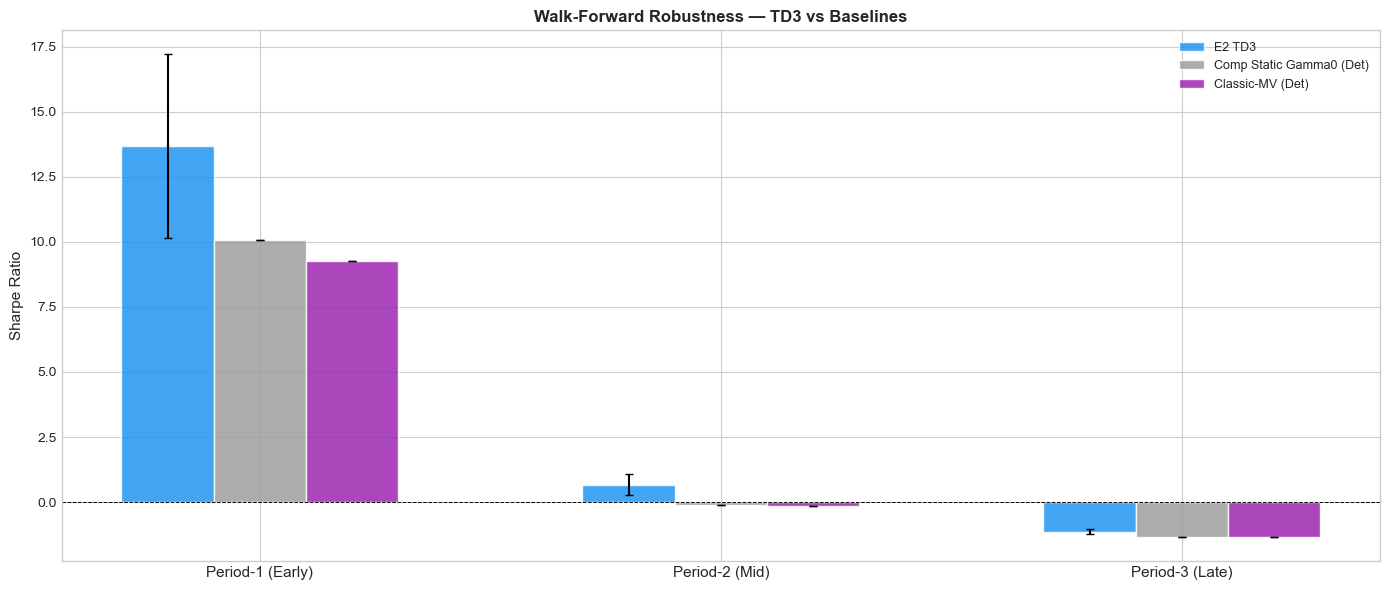

Saved: td3_ablation_results/td3_walkforward.png

Konsistensi E2_TD3 vs Classic-MV:
  Period-1 (Early): E2_TD3=13.6825 | Classic-MV=9.2685 | Δ=+4.4140 ✓
  Period-2 (Mid): E2_TD3=0.6660 | Classic-MV=-0.1490 | Δ=+0.8150 ✓
  Period-3 (Late): E2_TD3=-1.1298 | Classic-MV=-1.3414 | Δ=+0.2116 ✓


In [123]:

print('=== Walk-Forward Robustness Check (TD3) ===')
n_test = len(ret_test)
window_ids = [
    ('Period-1 (Early)', ret_test.iloc[:n_test // 3]),
    ('Period-2 (Mid)',   ret_test.iloc[n_test // 3: 2 * n_test // 3]),
    ('Period-3 (Late)',  ret_test.iloc[2 * n_test // 3:]),
]

wf_ids = ['E2_TD3', 'Comp_Static_Gamma0', 'Classic-MV']
wf_rows = []

for period_label, period_data in window_ids:
    print(f'{period_label}: {period_data.index[0].date()} – {period_data.index[-1].date()}')
    for exp_id in wf_ids:
        sharpes = []
        for seed in SEEDS:
            full_ret   = ablation_results[exp_id]['test'][seed]
            mask       = (full_ret.index >= period_data.index[0]) & (full_ret.index <= period_data.index[-1])
            period_ret = full_ret[mask]
            if len(period_ret) > 10:
                sharpes.append(calculate_sharpe_ratio(period_ret))
        if sharpes:
            wf_rows.append({'Period': period_label, 'Experiment': exp_id,
                            'Sharpe_Mean': np.mean(sharpes), 'Sharpe_Std': np.std(sharpes)})

wf_df = pd.DataFrame(wf_rows)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(window_ids))
width = 0.2
for i, exp_id in enumerate(wf_ids):
    exp_data = wf_df[wf_df['Experiment'] == exp_id]
    means    = exp_data['Sharpe_Mean'].values
    stds     = exp_data['Sharpe_Std'].values
    offset   = (i - len(wf_ids) / 2) * width + width / 2
    ax.bar(x + offset, means, width, yerr=stds, capsize=3,
           color=ABLATION_COLORS.get(exp_id, '#888'),
           label=get_display_name(exp_id), alpha=0.85, edgecolor='white')

ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels([p for p, _ in window_ids], fontsize=11)
ax.set_ylabel('Sharpe Ratio', fontsize=11)
ax.set_title('Walk-Forward Robustness — TD3 vs Baselines', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('td3_ablation_results/td3_walkforward.png', dpi=150, bbox_inches='tight')
plt.show()
wf_df.to_csv('td3_ablation_results/td3_walkforward_results.csv', index=False)
print('Saved: td3_ablation_results/td3_walkforward.png')

print('\nKonsistensi E2_TD3 vs Classic-MV:')
for period_label, _ in window_ids:
    p_s = wf_df[(wf_df['Period'] == period_label) & (wf_df['Experiment'] == 'E2_TD3')]['Sharpe_Mean'].values
    c_s = wf_df[(wf_df['Period'] == period_label) & (wf_df['Experiment'] == 'Classic-MV')]['Sharpe_Mean'].values
    if len(p_s) > 0 and len(c_s) > 0:
        delta = p_s[0] - c_s[0]
        sign  = '✓' if delta > 0 else '✗'
        print(f'  {period_label}: E2_TD3={p_s[0]:.4f} | Classic-MV={c_s[0]:.4f} | Δ={delta:+.4f} {sign}')




## FINAL DASHBOARD GENERATOR



Generating Final Dashboard for Test Period...


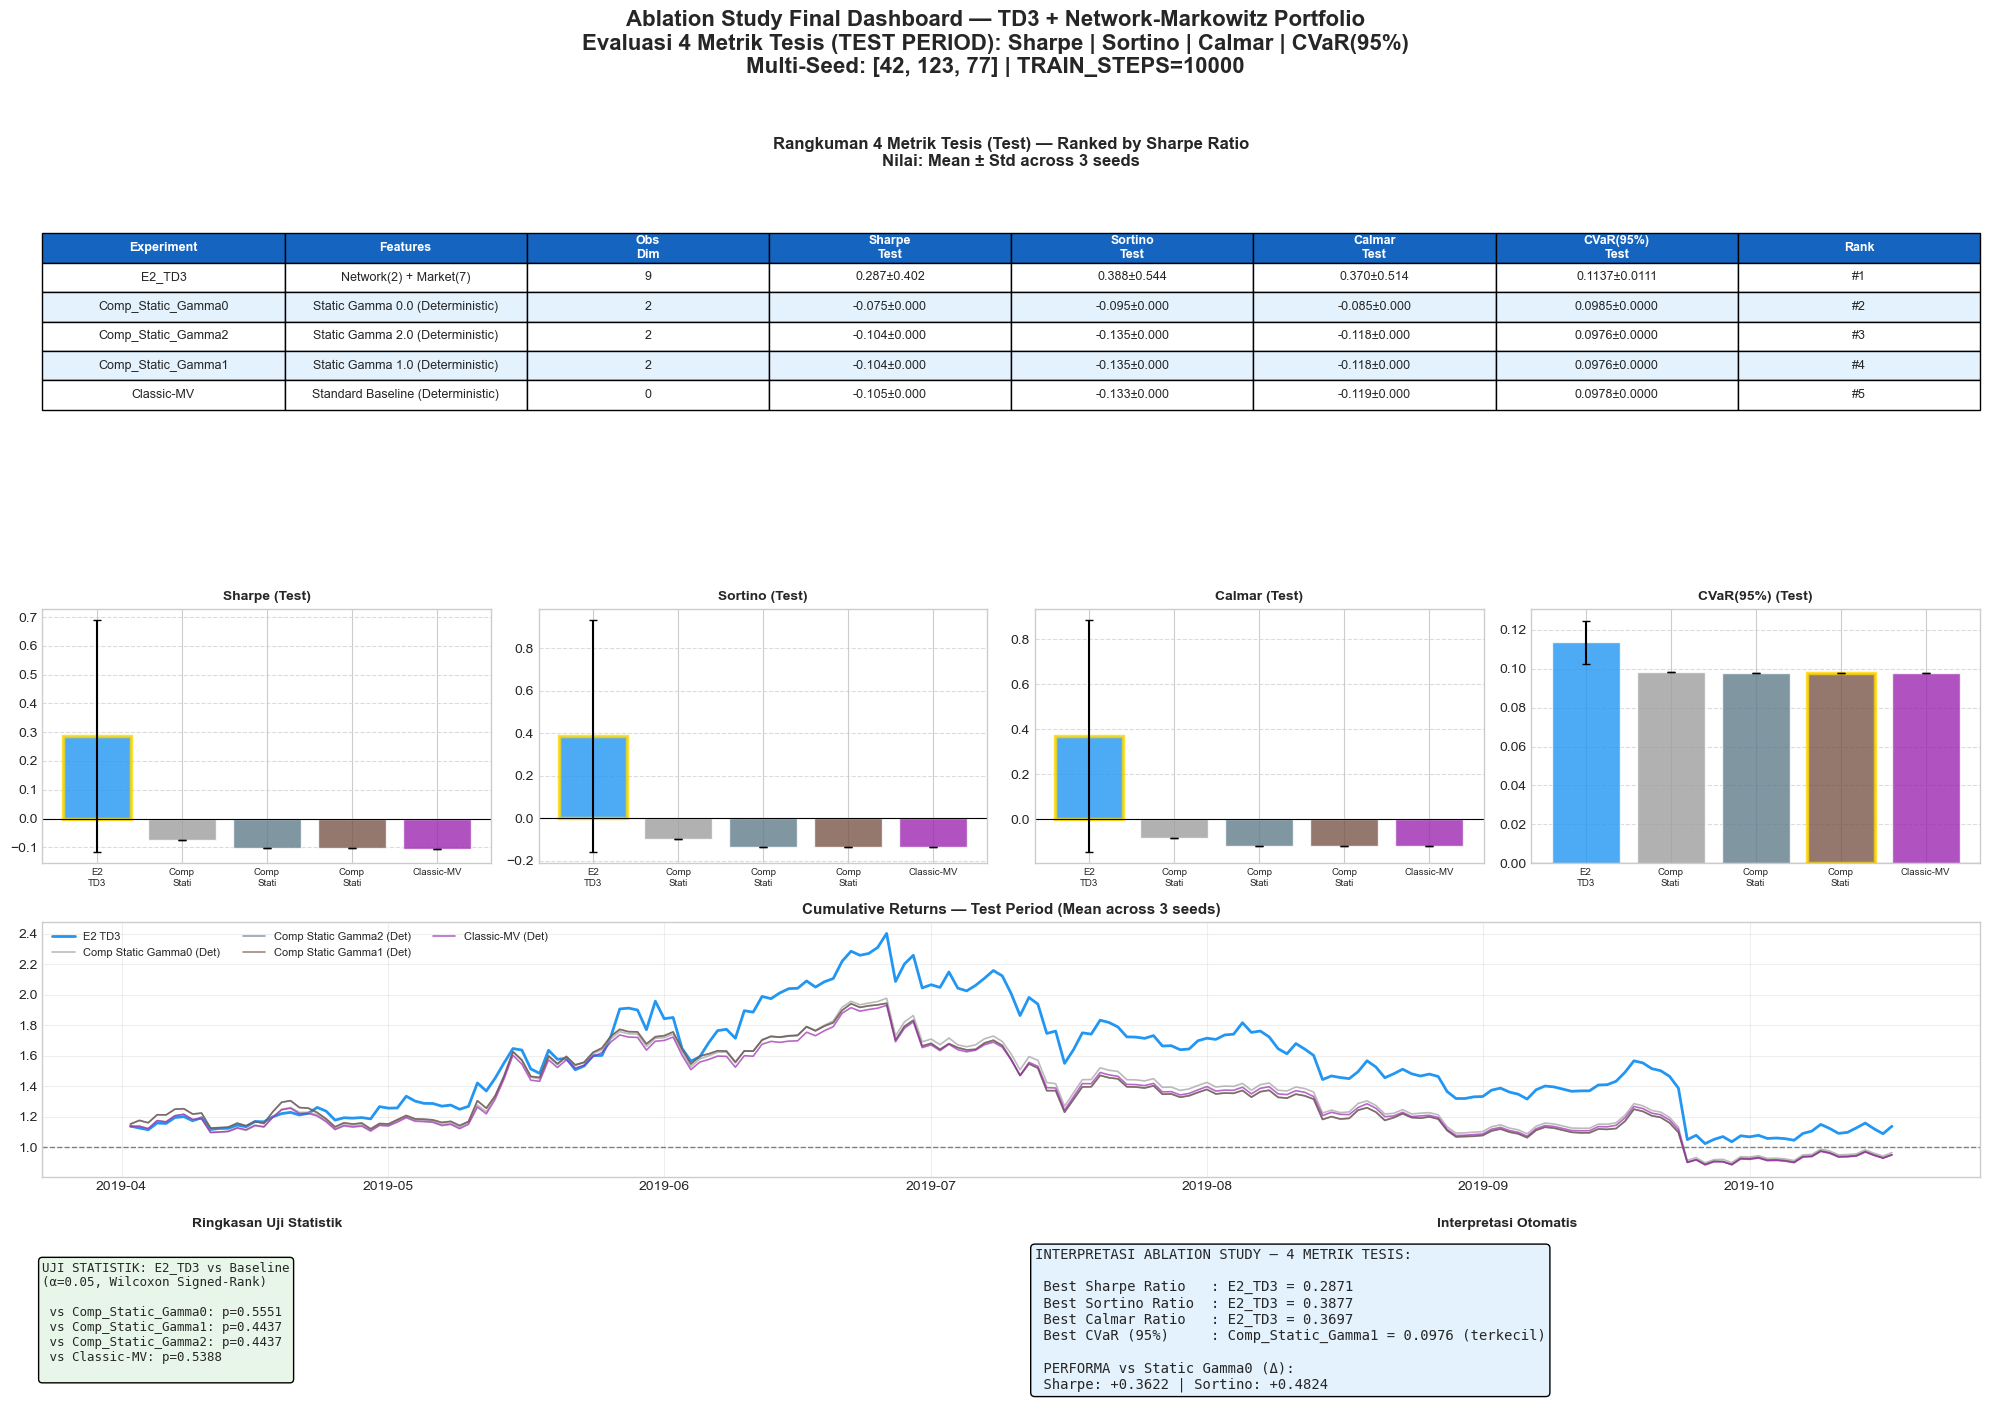

Dashboard saved: td3_ablation_results/td3_final_dashboard_test.png

Generating Final Dashboard for Train Period...


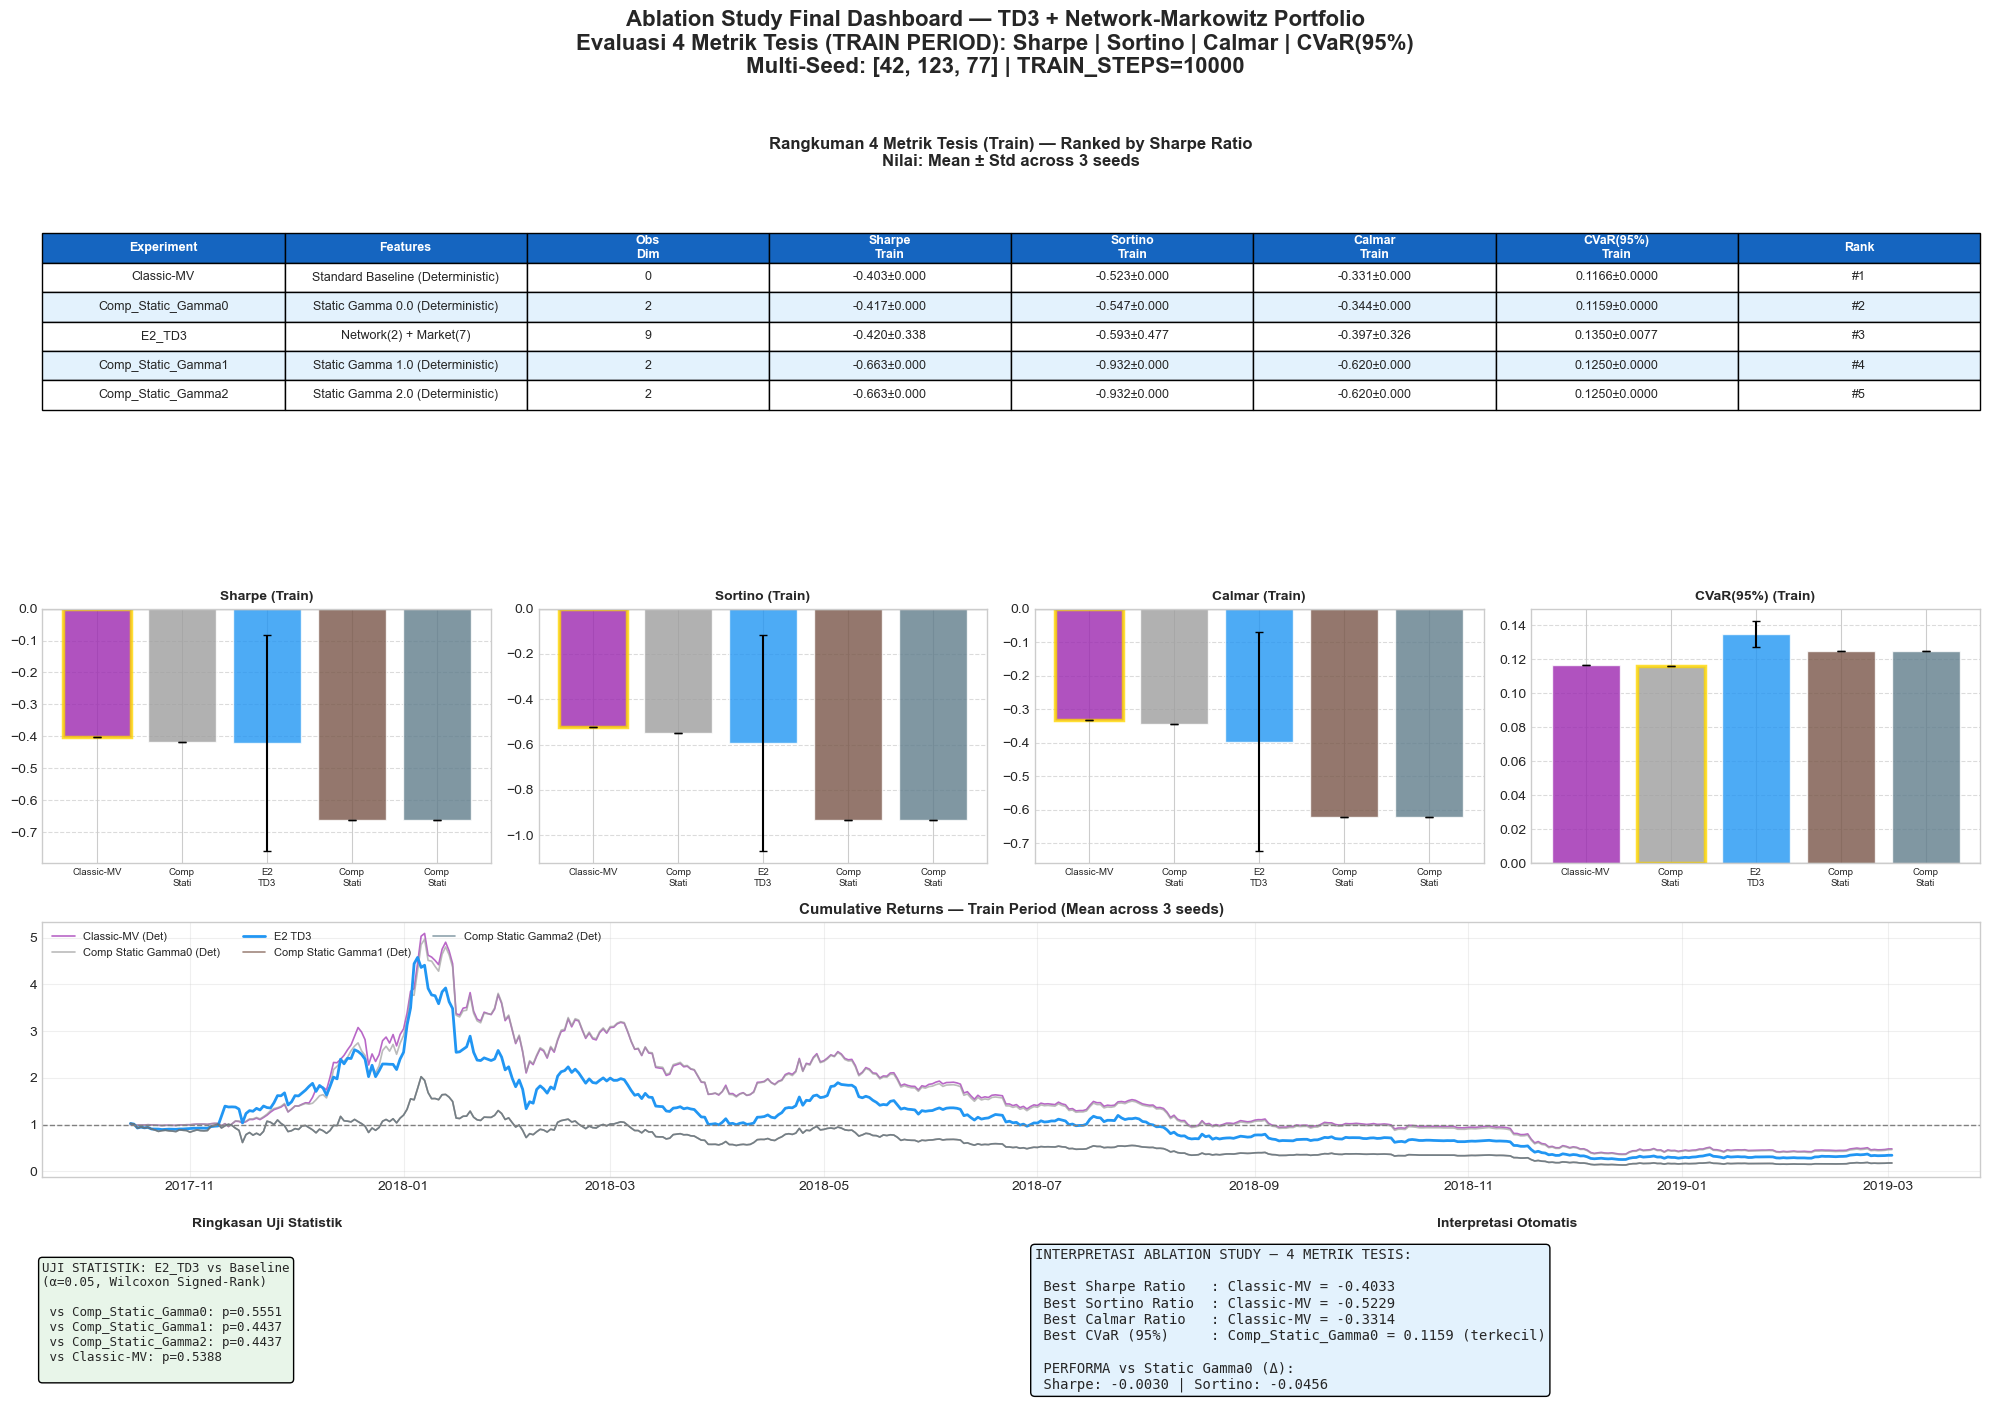

Dashboard saved: td3_ablation_results/td3_final_dashboard_train.png

Generating Policy Output Analysis (Gamma Dist & Correlation)...


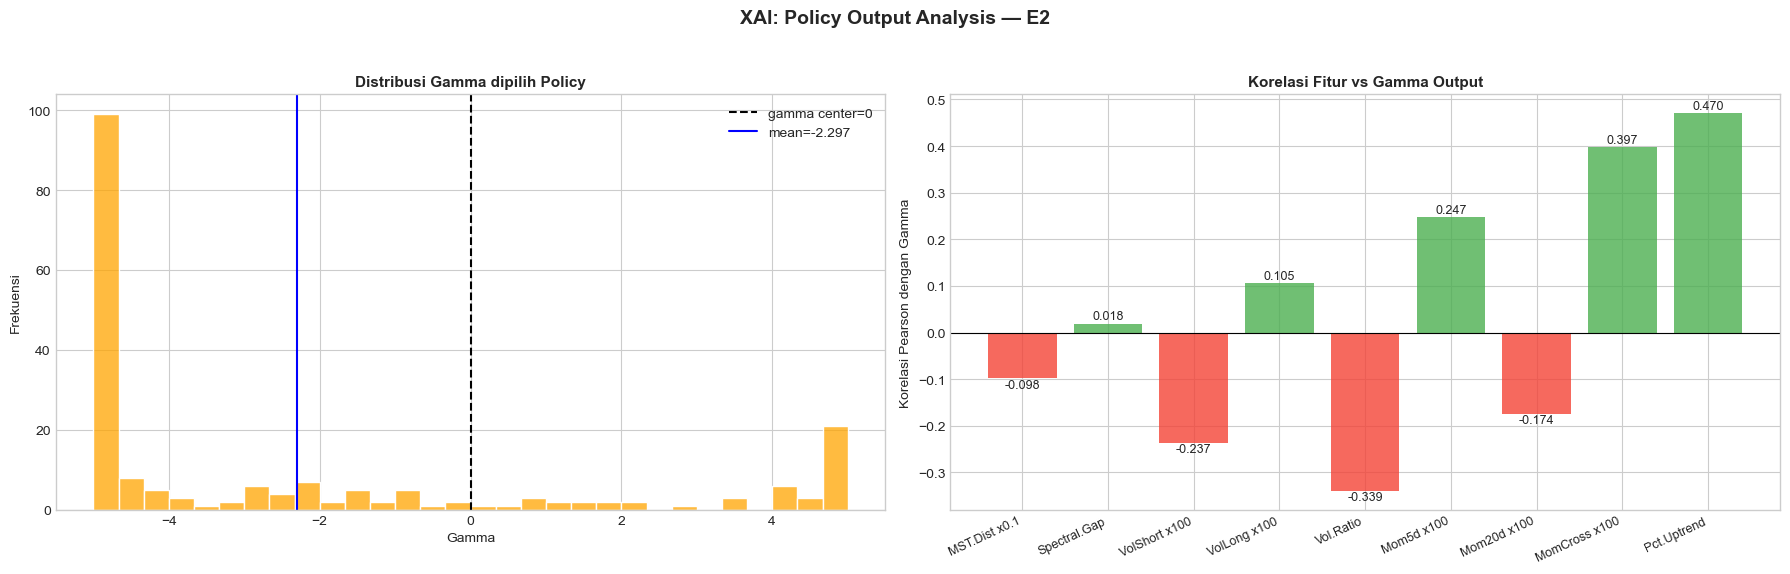

Policy Analysis saved: td3_ablation_results/td3_xai_policy_analysis.png

Generating Partial Dependence Plots (PDP)...


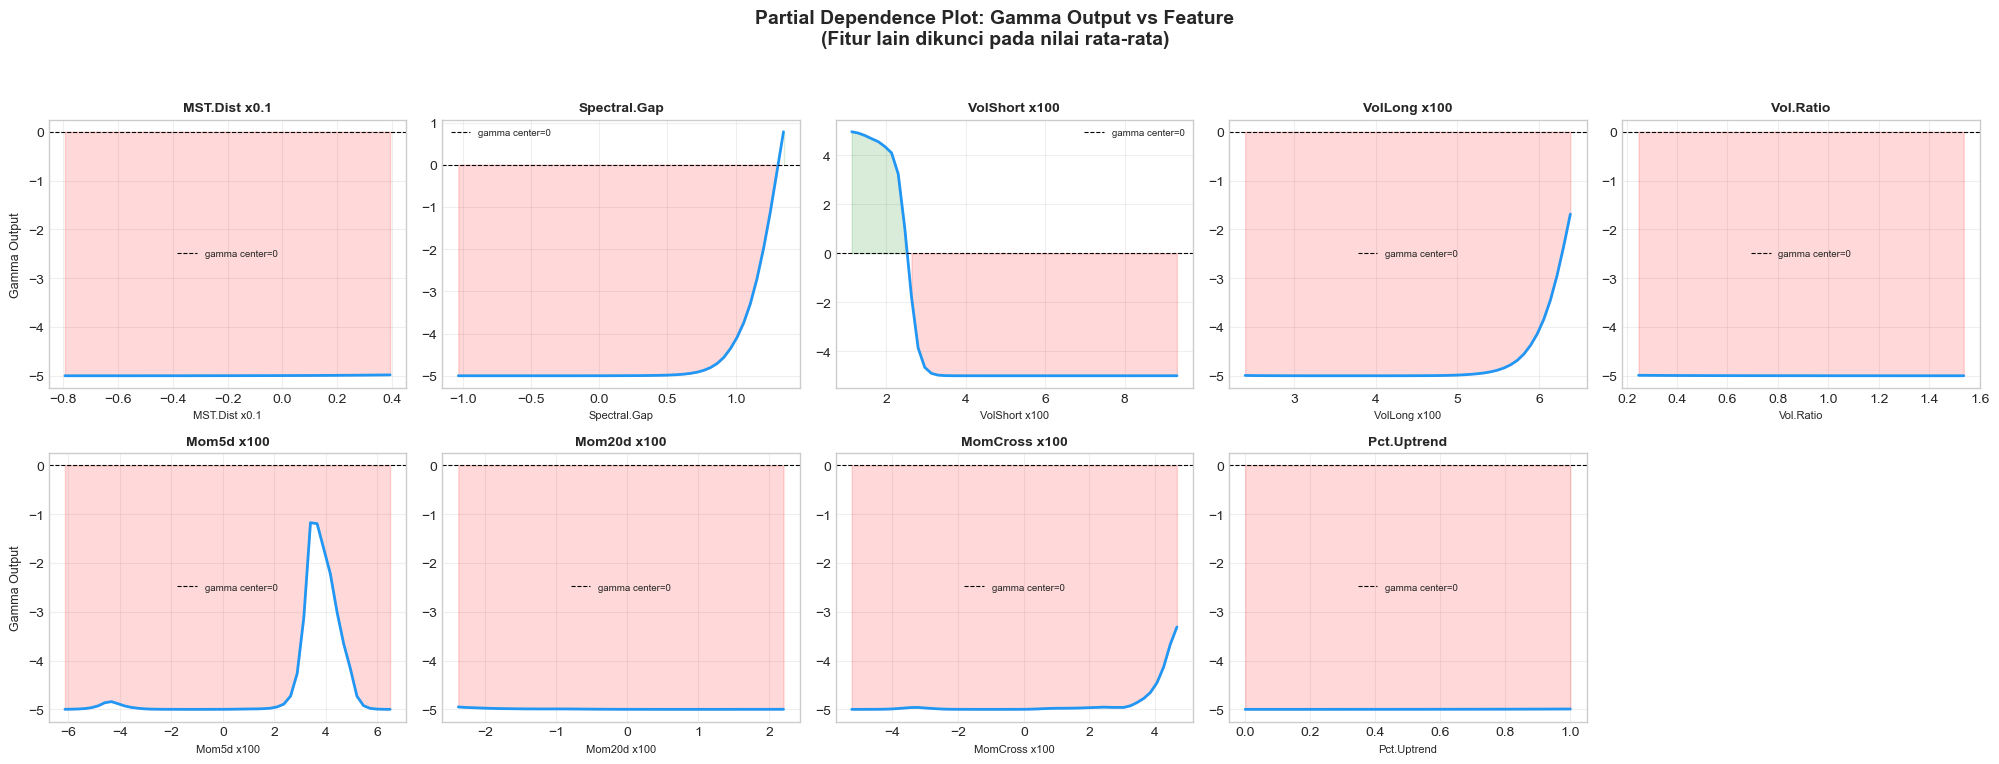

PDP Plot saved: td3_ablation_results/td3_xai_pdp.png

✅ TD3 Ablation Study Selesai!
Output disimpan di: td3_ablation_results/
  - td3_ablation_summary.csv
  - td3_statistical_tests.csv
  - td3_walkforward_results.csv
  - learning_curves_td3.png
  - td3_final_dashboard_test.png
  - td3_final_dashboard_train.png
  - td3_xai_policy_analysis.png
  - td3_xai_pdp.png
  - td3_xai_permutation.png


In [124]:

def create_final_dashboard(period='Test'):
    print(f'\nGenerating Final Dashboard for {period} Period...')
    
    # 1. Setup Data
    exp_ids = list(summary_df.index)
    # Sort by Sharpe Ratio
    sorted_df = summary_df.sort_values(f'SharpeRatio_{period}_Mean', ascending=False)
    sorted_ids = list(sorted_df.index)
    
    fig = plt.figure(figsize=(20, 15))
    gs = gridspec.GridSpec(5, 4, height_ratios=[1.2, 0.2, 1.2, 1.2, 0.8])
    
    # Title
    fig.suptitle(f'Ablation Study Final Dashboard — TD3 + Network-Markowitz Portfolio\n'
                 f'Evaluasi 4 Metrik Tesis ({period.upper()} PERIOD): Sharpe | Sortino | Calmar | CVaR(95%)\n'
                 f'Multi-Seed: {SEEDS} | TRAIN_STEPS={TRAIN_STEPS}', 
                 fontsize=16, fontweight='bold', y=0.97)

    # A. Summary Table (Top)
    ax_table = fig.add_subplot(gs[0, :])
    ax_table.axis('off')
    
    col_labels = ['Experiment', 'Features', 'Obs\nDim', 
                  f'Sharpe\n{period}', f'Sortino\n{period}', f'Calmar\n{period}', f'CVaR(95%)\n{period}', 'Rank']
    
    table_data = []
    for rank, (idx, row) in enumerate(sorted_df.iterrows(), 1):
        table_data.append([
            idx,
            row['Features'],
            int(row['Obs Dim']),
            f"{row[f'SharpeRatio_{period}_Mean']:.3f}±{row[f'SharpeRatio_{period}_Std']:.3f}",
            f"{row[f'SortinoRatio_{period}_Mean']:.3f}±{row[f'SortinoRatio_{period}_Std']:.3f}",
            f"{row[f'CalmarRatio_{period}_Mean']:.3f}±{row[f'CalmarRatio_{period}_Std']:.3f}",
            f"{row[f'CVaR95pct_{period}_Mean']:.4f}±{row[f'CVaR95pct_{period}_Std']:.4f}",
            f'#{rank}'
        ])
    
    tbl = ax_table.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.8)
    
    # Style Table
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#1565C0')
        tbl[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(1, len(table_data) + 1):
        face_color = '#E3F2FD' if i % 2 == 0 else 'white'
        for j in range(len(col_labels)):
            tbl[i, j].set_facecolor(face_color)

    ax_table.set_title(f'Rangkuman 4 Metrik Tesis ({period}) — Ranked by Sharpe Ratio\nNilai: Mean ± Std across {len(SEEDS)} seeds', 
                       fontsize=12, fontweight='bold', pad=20)

    # B. Bar Charts (Middle)
    metrics_info = [
        (f'SharpeRatio_{period}_Mean', f'SharpeRatio_{period}_Std', 'Sharpe', False),
        (f'SortinoRatio_{period}_Mean', f'SortinoRatio_{period}_Std', 'Sortino', False),
        (f'CalmarRatio_{period}_Mean', f'CalmarRatio_{period}_Std', 'Calmar', False),
        (f'CVaR95pct_{period}_Mean', f'CVaR95pct_{period}_Std', 'CVaR(95%)', True),
    ]
    
    for i, (m_col, s_col, label, lower_better) in enumerate(metrics_info):
        ax = fig.add_subplot(gs[2, i])
        vals = sorted_df[m_col].values
        errs = sorted_df[s_col].values
        colors = [ABLATION_COLORS.get(idx, '#888') for idx in sorted_ids]
        
        bars = ax.bar(range(len(sorted_ids)), vals, yerr=errs, color=colors, 
                      edgecolor='white', capsize=3, alpha=0.8)
        
        # Highlight Best
        best_idx = np.argmin(vals) if lower_better else np.argmax(vals)
        bars[best_idx].set_edgecolor('gold')
        bars[best_idx].set_linewidth(2.5)
        
        ax.set_xticks(range(len(sorted_ids)))
        ax.set_xticklabels([idx.replace('_', '\n')[:10] for idx in sorted_ids], fontsize=7)
        ax.set_title(f'{label} ({period})', fontsize=10, fontweight='bold')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.grid(axis='y', linestyle='--', alpha=0.7)

    # C. Cumulative Returns (Bottom)
    ax_cum = fig.add_subplot(gs[3, :])
    period_key = period.lower()
    for exp_id in sorted_ids:
        if exp_id in ablation_results:
            mean_ret = _mean_cumret(ablation_results, exp_id, period_key)
            cum = (1 + mean_ret).cumprod()
            lw = 2.0 if exp_id == 'E2_TD3' else 1.2
            alpha = 1.0 if exp_id == 'E2_TD3' else 0.7
            ax_cum.plot(cum, label=get_display_name(exp_id), 
                        color=ABLATION_COLORS.get(exp_id, '#888'), linewidth=lw, alpha=alpha)
    
    ax_cum.set_title(f'Cumulative Returns — {period} Period (Mean across {len(SEEDS)} seeds)', fontsize=11, fontweight='bold')
    ax_cum.axhline(1.0, color='gray', linestyle='--', linewidth=1.0)
    ax_cum.legend(fontsize=8, ncol=3, loc='upper left')
    ax_cum.grid(True, alpha=0.3)

    # D. Boxes (Interpretasi)
    # Box 1: Statistik
    ax_box1 = fig.add_subplot(gs[4, 0:1])
    ax_box1.axis('off')
    
    proposed = 'E2_TD3'
    stat_text = f"UJI STATISTIK: {proposed} vs Baseline\n(α=0.05, Wilcoxon Signed-Rank)\n\n"
    if 'stat_df' in globals():
        for _, r in stat_df.iterrows():
            stat_text += f" vs {r['Compared_to']}: p={r['p_value']:.4f}\n"
    
    ax_box1.text(0, 0.5, stat_text, fontsize=9, bbox=dict(boxstyle='round', facecolor='#E8F5E9', alpha=1.0),
                 verticalalignment='center', fontfamily='monospace')
    ax_box1.set_title('Ringkasan Uji Statistik', fontsize=10, fontweight='bold')

    # Box 2: Interpretasi Otomatis
    ax_box2 = fig.add_subplot(gs[4, 2:4])
    ax_box2.axis('off')
    
    best_sharpe = sorted_ids[0]
    best_cvar = sorted_df[f'CVaR95pct_{period}_Mean'].idxmin()
    
    interp_text = f"INTERPRETASI ABLATION STUDY — 4 METRIK TESIS:\n\n"
    interp_text += f" Best Sharpe Ratio   : {best_sharpe} = {sorted_df.loc[best_sharpe, f'SharpeRatio_{period}_Mean']:.4f}\n"
    interp_text += f" Best Sortino Ratio  : {sorted_df[f'SortinoRatio_{period}_Mean'].idxmax()} = {sorted_df[f'SortinoRatio_{period}_Mean'].max():.4f}\n"
    interp_text += f" Best Calmar Ratio   : {sorted_df[f'CalmarRatio_{period}_Mean'].idxmax()} = {sorted_df[f'CalmarRatio_{period}_Mean'].max():.4f}\n"
    interp_text += f" Best CVaR (95%)     : {best_cvar} = {sorted_df.loc[best_cvar, f'CVaR95pct_{period}_Mean']:.4f} (terkecil)\n\n"
    
    if 'E2_TD3' in sorted_ids and 'Comp_Static_Gamma0' in sorted_ids:
        diff_sharpe = sorted_df.loc['E2_TD3', f'SharpeRatio_{period}_Mean'] - sorted_df.loc['Comp_Static_Gamma0', f'SharpeRatio_{period}_Mean']
        interp_text += f" PERFORMA vs Static Gamma0 (Δ):\n Sharpe: {diff_sharpe:+.4f} | "
        diff_sort = sorted_df.loc['E2_TD3', f'SortinoRatio_{period}_Mean'] - sorted_df.loc['Comp_Static_Gamma0', f'SortinoRatio_{period}_Mean']
        interp_text += f"Sortino: {diff_sort:+.4f}"

    ax_box2.text(0, 0.5, interp_text, fontsize=10, bbox=dict(boxstyle='round', facecolor='#E3F2FD', alpha=1.0),
                 verticalalignment='center', fontfamily='monospace')
    ax_box2.set_title('Interpretasi Otomatis', fontsize=10, fontweight='bold')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    save_path = f'td3_ablation_results/td3_final_dashboard_{period.lower()}.png'
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Dashboard saved: {save_path}')

def plot_pdp_analysis():
    print('\nGenerating Partial Dependence Plots (PDP)...')
    # Use obs_array and model_xai from Permutation section
    n_features = len(FEATURE_NAMES)
    ncols = 5
    nrows = (n_features + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
    fig.suptitle('Partial Dependence Plot: Gamma Output vs Feature\n(Fitur lain dikunci pada nilai rata-rata)', 
                 fontsize=14, fontweight='bold')
    
    axes_flat = axes.flatten()
    mean_obs = obs_array.mean(axis=0)
    
    for i in range(n_features):
        ax = axes_flat[i]
        f_min, f_max = obs_array[:, i].min(), obs_array[:, i].max()
        f_range = np.linspace(f_min, f_max, 50)
        
        gammas = []
        for val in f_range:
            test_obs = mean_obs.copy()
            test_obs[i] = val
            action, _ = model_xai.predict(test_obs.astype(np.float32), deterministic=True)
            gamma = float(np.clip(action[0], -1.0, 1.0)) * 5.0 + GAMMA_CENTER
            gammas.append(gamma)
        
        ax.plot(f_range, gammas, color='#2196F3', linewidth=2)
        ax.fill_between(f_range, gammas, 0, where=np.array(gammas) > 0, color='green', alpha=0.15)
        ax.fill_between(f_range, gammas, 0, where=np.array(gammas) < 0, color='red', alpha=0.15)
        
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8, label='gamma center=0')
        ax.set_title(FEATURE_NAMES[i], fontsize=10, fontweight='bold')
        ax.set_xlabel(FEATURE_NAMES[i], fontsize=8)
        if i % ncols == 0:
            ax.set_ylabel('Gamma Output', fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)

    for ax in axes_flat[n_features:]:
        ax.set_visible(False)
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('td3_ablation_results/td3_xai_pdp.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('PDP Plot saved: td3_ablation_results/td3_xai_pdp.png')

def plot_policy_output_analysis():
    print('\nGenerating Policy Output Analysis (Gamma Dist & Correlation)...')
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('XAI: Policy Output Analysis — E2', fontsize=14, fontweight='bold')
    
    # 1. Histogram of Gamma
    ax1 = axes[0]
    sns.histplot(gamma_array, bins=30, kde=False, color='orange', ax=ax1, edgecolor='white')
    ax1.axvline(0, color='black', linestyle='--', label='gamma center=0')
    ax1.axvline(gamma_array.mean(), color='blue', label=f'mean={gamma_array.mean():.3f}')
    ax1.set_title('Distribusi Gamma dipilih Policy', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Gamma')
    ax1.set_ylabel('Frekuensi')
    ax1.legend()
    
    # 2. Correlation Bar Chart
    ax2 = axes[1]
    corrs = []
    for i in range(len(FEATURE_NAMES)):
        c, _ = stats.pearsonr(obs_array[:, i], gamma_array)
        corrs.append(c)
    
    colors = ['#4CAF50' if c > 0 else '#F44336' for c in corrs]
    bars = ax2.bar(FEATURE_NAMES, corrs, color=colors, alpha=0.8)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_title('Korelasi Fitur vs Gamma Output', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Korelasi Pearson dengan Gamma')
    ax2.set_xticklabels(FEATURE_NAMES, rotation=25, ha='right', fontsize=9)
    
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, h + (0.01 if h > 0 else -0.02),
                 f'{h:.3f}', ha='center', fontsize=9)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('td3_ablation_results/td3_xai_policy_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Policy Analysis saved: td3_ablation_results/td3_xai_policy_analysis.png')

# Run new visualizations
create_final_dashboard(period='Test')
create_final_dashboard(period='Train')
plot_policy_output_analysis()
plot_pdp_analysis()

print('\n' + '=' * 60)
print('✅ TD3 Ablation Study Selesai!')
print('Output disimpan di: td3_ablation_results/')
for f in [
    'td3_ablation_summary.csv',
    'td3_statistical_tests.csv',
    'td3_walkforward_results.csv',
    'learning_curves_td3.png',
    'td3_final_dashboard_test.png',
    'td3_final_dashboard_train.png',
    'td3_xai_policy_analysis.png',
    'td3_xai_pdp.png',
    'td3_xai_permutation.png',
]:
    print(f'  - {f}')
print('=' * 60)

